## Data Cleaning
The raw dataset contains 19,382 rows and 12 columns.
298 rows had missing engagement data and were dropped,
leaving 19,084 clean rows for analysis.
A total_engagement column was created by summing likes, comments, and shares.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('tiktok_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (19382, 12)

Columns: ['#', 'claim_status', 'video_id', 'video_duration_sec', 'video_transcription_text', 'verified_status', 'author_ban_status', 'video_view_count', 'video_like_count', 'video_share_count', 'video_download_count', 'video_comment_count']

First 5 rows:


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [21]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic stats:")
df.describe()

Missing values:
#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

Data types:
#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Basic stats:


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [22]:
df_clean = df.dropna()

print("Rows before:", len(df))
print("Rows after:", len(df_clean))
print("Rows dropped:", len(df) - len(df_clean))

Rows before: 19382
Rows after: 19084
Rows dropped: 298


In [23]:
df_clean = df_clean.copy()

df_clean['total_engagement'] = (
    df_clean['video_like_count'] +
    df_clean['video_comment_count'] +
    df_clean['video_share_count']
)

df_clean['engagement_rate'] = (
    df_clean['total_engagement'] / df_clean['video_view_count']
)

print("New columns added successfully")
df_clean[['video_view_count', 'total_engagement', 'engagement_rate']].head()

New columns added successfully


,video_view_count,total_engagement,engagement_rate
0,343296.0,19666.0,0.057286
1,140877.0,97073.0,0.689062
2,902185.0,100877.0,0.111814
3,437506.0,275350.0,0.629363
4,56167.0,39249.0,0.698791


## Question 1: Do claim videos or opinion videos get more engagement?

Claim videos and opinion videos represent fundamentally different types of content on TikTok.
This analysis explores whether these two content types show different engagement behaviour,
specifically in terms of views, likes, shares, and overall engagement rate.

In [24]:
claim_analysis = df_clean.groupby('claim_status').agg(
    avg_views=('video_view_count', 'mean'),
    avg_likes=('video_like_count', 'mean'),
    avg_shares=('video_share_count', 'mean'),
    avg_comments=('video_comment_count', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    video_count=('video_id', 'count')
).round(2)

print(claim_analysis)

              avg_views  avg_likes  avg_shares  avg_comments  \
claim_status                                                   
claim         501029.45  166373.33    33026.42        691.16   
opinion         4956.43    1092.73      217.15          2.70   

              avg_engagement_rate  video_count  
claim_status                                    
claim                        0.40         9608  
opinion                      0.26         9476  


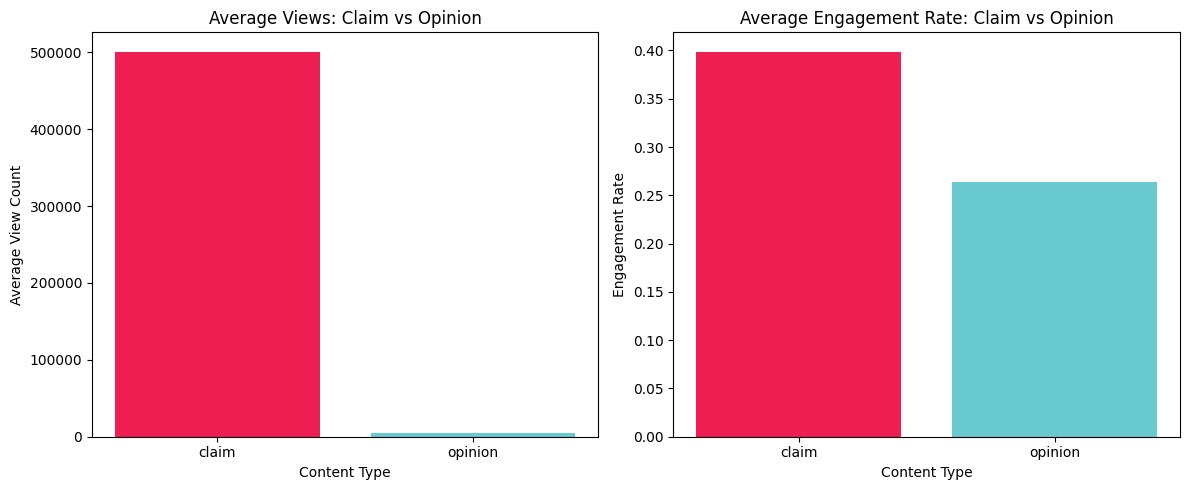

Chart saved!


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

categories = ['claim', 'opinion']
avg_views = [
    df_clean[df_clean['claim_status']=='claim']['video_view_count'].mean(),
    df_clean[df_clean['claim_status']=='opinion']['video_view_count'].mean()
]

axes[0].bar(categories, avg_views, color=['#EE1D52', '#69C9D0'])
axes[0].set_title('Average Views: Claim vs Opinion')
axes[0].set_ylabel('Average View Count')
axes[0].set_xlabel('Content Type')

avg_er = [
    df_clean[df_clean['claim_status']=='claim']['engagement_rate'].mean(),
    df_clean[df_clean['claim_status']=='opinion']['engagement_rate'].mean()
]

axes[1].bar(categories, avg_er, color=['#EE1D52', '#69C9D0'])
axes[1].set_title('Average Engagement Rate: Claim vs Opinion')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xlabel('Content Type')

plt.tight_layout()
plt.savefig('claim_vs_opinion.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

### Finding
Claim videos receive approximately 100x more views than opinion videos on average
(501,029 vs 4,956), with consistently higher engagement across all metrics.
This suggests claim-based content spreads significantly further on the platform,
raising questions about whether algorithmic amplification plays a role.

## Question 2: Does author verification status affect how far videos spread?

Verified accounts carry an implicit trust signal on TikTok.
This analysis explores whether videos from verified authors reach wider audiences
and generate more engagement compared to unverified authors.

In [26]:
verified_analysis = df_clean.groupby('verified_status').agg(
    avg_views=('video_view_count', 'mean'),
    avg_shares=('video_share_count', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    video_count=('video_id', 'count')
).round(2)

print(verified_analysis)

                 avg_views  avg_shares  avg_engagement_rate  video_count
verified_status                                                         
not verified     265663.79    17415.89                 0.33        17884
verified          91439.16     6591.45                 0.29         1200


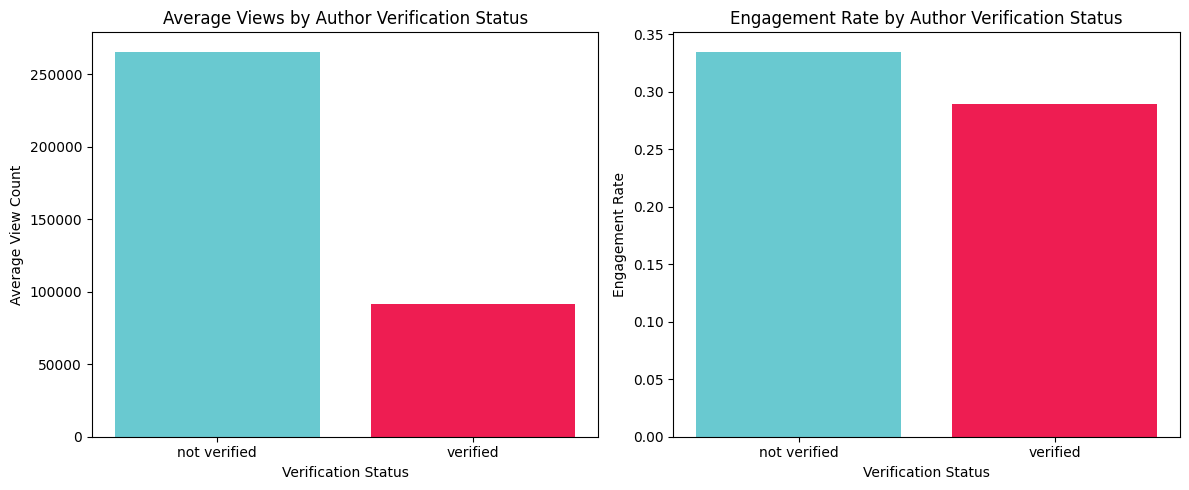

Chart saved!


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

verified_groups = df_clean.groupby('verified_status')['video_view_count'].mean()
axes[0].bar(verified_groups.index, verified_groups.values, color=['#69C9D0', '#EE1D52'])
axes[0].set_title('Average Views by Author Verification Status')
axes[0].set_ylabel('Average View Count')
axes[0].set_xlabel('Verification Status')

verified_er = df_clean.groupby('verified_status')['engagement_rate'].mean()
axes[1].bar(verified_er.index, verified_er.values, color=['#69C9D0', '#EE1D52'])
axes[1].set_title('Engagement Rate by Author Verification Status')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xlabel('Verification Status')

plt.tight_layout()
plt.savefig('verified_vs_unverified.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

### Finding
Counterintuitively, unverified authors outperform verified authors in average views
(265,663 vs 91,439) and shares. This is unexpected as verification is generally
associated with credibility and reach.

One likely explanation: unverified authors account for 94% of videos in this dataset
(17,884 vs 1,200 videos), and this group may include authors who were later banned
or placed under scrutiny, authors who potentially accumulated high views through
misinformation or manipulation before being actioned by TikTok's trust and safety team.

This raises a key question: are high-engagement videos more likely to come from
banned accounts? This is examined in Question 3.

## Question 3: Do banned accounts show different engagement patterns?

The previous analysis raised a question: could banned or flagged accounts be
driving the unexpectedly high engagement seen among unverified authors?

This analysis examines whether author ban status correlates with engagement levels,
which could help identify at-risk accounts earlier in the content lifecycle.

In [28]:
ban_analysis = df_clean.groupby('author_ban_status').agg(
    avg_views=('video_view_count', 'mean'),
    avg_likes=('video_like_count', 'mean'),
    avg_shares=('video_share_count', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    video_count=('video_id', 'count')
).round(2)

print(ban_analysis)

                   avg_views  avg_likes  avg_shares  avg_engagement_rate  \
author_ban_status                                                          
active             215927.04   71036.53    14111.47                 0.32   
banned             445845.44  153017.24    29998.94                 0.39   
under review       392204.84  128718.05    25774.70                 0.37   

                   video_count  
author_ban_status               
active                   15383  
banned                    1635  
under review              2066  


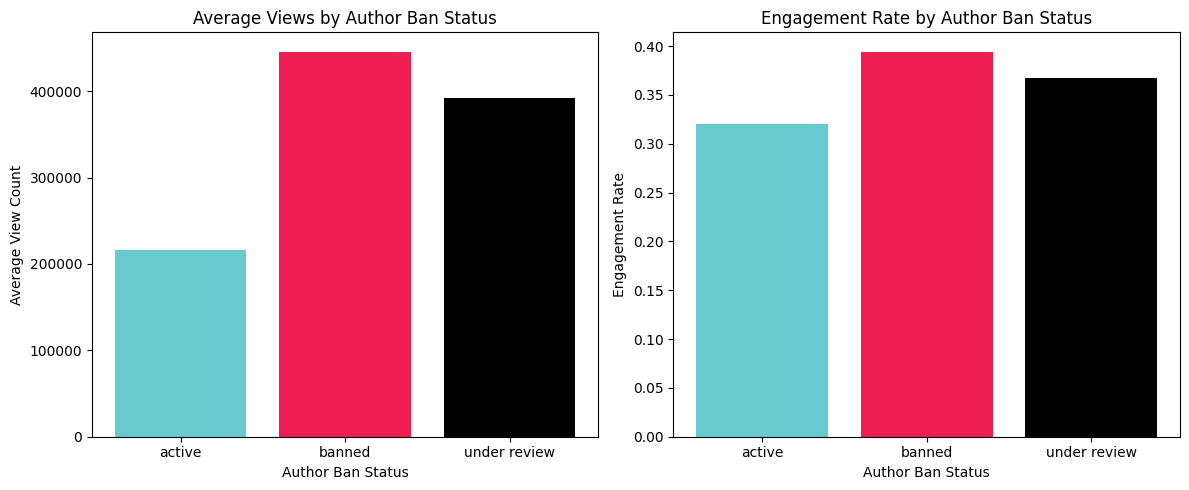

Chart saved!


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ban_views = df_clean.groupby('author_ban_status')['video_view_count'].mean()
axes[0].bar(ban_views.index, ban_views.values, color=['#69C9D0', '#EE1D52', '#010101'])
axes[0].set_title('Average Views by Author Ban Status')
axes[0].set_ylabel('Average View Count')
axes[0].set_xlabel('Author Ban Status')

ban_er = df_clean.groupby('author_ban_status')['engagement_rate'].mean()
axes[1].bar(ban_er.index, ban_er.values, color=['#69C9D0', '#EE1D52', '#010101'])
axes[1].set_title('Engagement Rate by Author Ban Status')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xlabel('Author Ban Status')

plt.tight_layout()
plt.savefig('ban_status_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

### Finding
Banned accounts generated more than double the average views of active accounts
(445,845 vs 215,927), with accounts under review sitting in between (392,204).
Engagement rate follows the same pattern: banned accounts score highest at 0.39, compared to 0.32 for active accounts.

This aligns with the hypothesis from the previous analysis. Videos from accounts
that were eventually banned were already attracting significantly more views and
interactions, suggesting that engagement velocity could serve as an early indicator
for content review prioritisation.

## Question 4: Which combination of author status and content type drives the most engagement?

The previous analyses examined claim status and author ban status separately.
This analysis combines both dimensions to understand which specific group
of videos is driving the highest engagement on the platform.

In [30]:
cross_analysis = df_clean.groupby(
    ['author_ban_status', 'claim_status'], observed=True
).agg(
    avg_views=('video_view_count', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean'),
    video_count=('video_id', 'count')
).round(2)

print(cross_analysis)

                                avg_views  avg_engagement_rate  video_count
author_ban_status claim_status                                             
active            claim         499221.73                 0.40         6566
                  opinion         4958.12                 0.26         8817
banned            claim         505907.92                 0.41         1439
                  opinion         4876.53                 0.25          196
under review      claim         504054.64                 0.40         1603
                  opinion         4958.11                 0.27          463


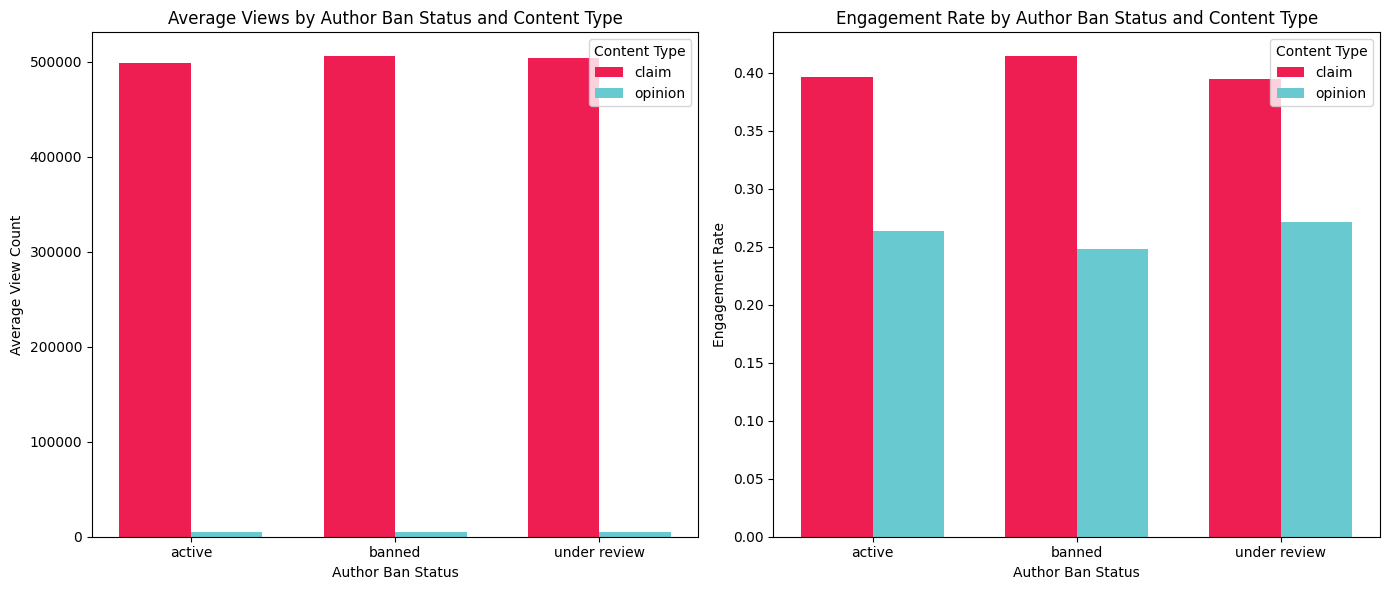

Chart saved!


In [31]:
import numpy as np

ban_statuses = ['active', 'banned', 'under review']
claim_types = ['claim', 'opinion']

x = np.arange(len(ban_statuses))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, claim in enumerate(claim_types):
    values = [
        df_clean[
            (df_clean['author_ban_status'] == ban) &
            (df_clean['claim_status'] == claim)
        ]['video_view_count'].mean()
        for ban in ban_statuses
    ]
    axes[0].bar(x + i * width, values, width,
                label=claim,
                color='#EE1D52' if claim == 'claim' else '#69C9D0')

axes[0].set_title('Average Views by Author Ban Status and Content Type')
axes[0].set_ylabel('Average View Count')
axes[0].set_xlabel('Author Ban Status')
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(ban_statuses)
axes[0].legend(title='Content Type')

for i, claim in enumerate(claim_types):
    values = [
        df_clean[
            (df_clean['author_ban_status'] == ban) &
            (df_clean['claim_status'] == claim)
        ]['engagement_rate'].mean()
        for ban in ban_statuses
    ]
    axes[1].bar(x + i * width, values, width,
                label=claim,
                color='#EE1D52' if claim == 'claim' else '#69C9D0')

axes[1].set_title('Engagement Rate by Author Ban Status and Content Type')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xlabel('Author Ban Status')
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(ban_statuses)
axes[1].legend(title='Content Type')

plt.tight_layout()
plt.savefig('cross_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

### Finding
Banned accounts posting claim videos drive the highest average views (505,907),
followed closely by accounts under review posting claim videos (504,054).
Opinion videos remain consistently low across all groups at around 4,900 views
regardless of author ban status.

This is worth noting because the figures for banned and under review accounts
reflect views accumulated before any account action was taken. The consistency
of average view count across all three account states suggests that content type
is the dominant factor driving viewership volume. Whether a video makes a claim
or expresses an opinion appears to matter far more than the account status of
the author posting it.

## Question 5: Is engagement concentrated among a small number of videos?

High average engagement figures can be misleading if a small number of viral
videos are pulling the numbers up. This analysis examines how engagement
is distributed across the dataset to understand whether high viewership
is a common or rare occurrence.

In [32]:
df_clean['view_decile'] = pd.qcut(
    df_clean['video_view_count'],
    q=10,
    labels=['D1\n(lowest)', 'D2', 'D3', 'D4', 'D5',
            'D6', 'D7', 'D8', 'D9', 'D10\n(highest)']
)

decile_analysis = df_clean.groupby('view_decile', observed=True).agg(
    avg_views=('video_view_count', 'mean'),
    total_views=('video_view_count', 'sum'),
    video_count=('video_id', 'count')
).round(2)

decile_analysis['pct_of_total_views'] = (
    decile_analysis['total_views'] /
    decile_analysis['total_views'].sum() * 100
).round(2)

print(decile_analysis)

                avg_views   total_views  video_count  pct_of_total_views
view_decile                                                             
D1\n(lowest)       955.58  1.825166e+06         1910                0.04
D2                2977.46  5.680993e+06         1908                0.12
D3                4944.38  9.428938e+06         1907                0.19
D4                6923.78  1.322443e+07         1910                0.27
D5                8933.49  1.703616e+07         1907                0.35
D6              102626.54  1.958114e+08         1908                4.03
D7              303310.58  5.790199e+08         1909               11.91
D8              505601.96  9.646885e+08         1908               19.85
D9              707006.12  1.348968e+09         1908               27.75
D10\n(highest)  903706.07  1.725175e+09         1909               35.49


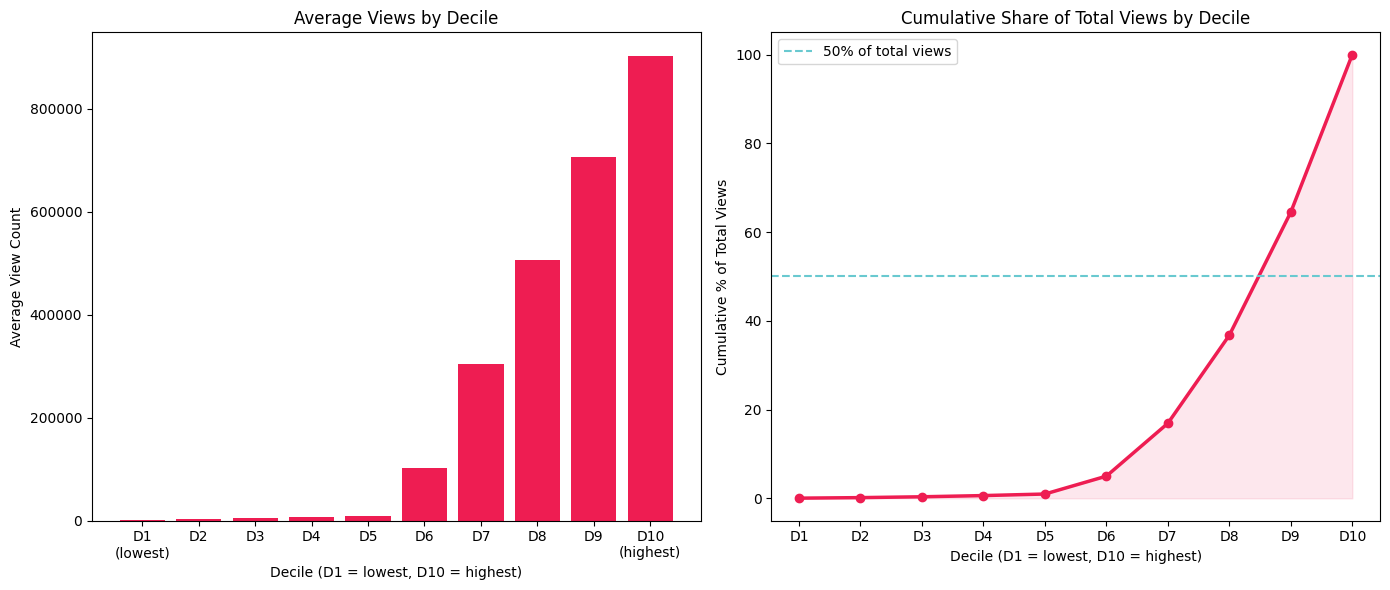

Chart saved!


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

decile_views = df_clean.groupby(
    'view_decile', observed=True)['video_view_count'].mean()
axes[0].bar(decile_views.index, decile_views.values, color='#EE1D52')
axes[0].set_title('Average Views by Decile')
axes[0].set_ylabel('Average View Count')
axes[0].set_xlabel('Decile (D1 = lowest, D10 = highest)')

cumulative_pct = decile_analysis['pct_of_total_views'].cumsum()
axes[1].plot(range(1, 11), cumulative_pct.values,
             color='#EE1D52', marker='o', linewidth=2.5)
axes[1].axhline(y=50, color='#69C9D0', linestyle='--', linewidth=1.5,
                label='50% of total views')
axes[1].fill_between(range(1, 11), cumulative_pct.values, alpha=0.1, color='#EE1D52')
axes[1].set_title('Cumulative Share of Total Views by Decile')
axes[1].set_ylabel('Cumulative % of Total Views')
axes[1].set_xlabel('Decile (D1 = lowest, D10 = highest)')
axes[1].set_xticks(range(1, 11))
axes[1].set_xticklabels(['D1', 'D2', 'D3', 'D4', 'D5',
                          'D6', 'D7', 'D8', 'D9', 'D10'])
axes[1].legend()

plt.tight_layout()
plt.savefig('view_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [34]:
top_20_pct = decile_analysis['pct_of_total_views'].iloc[-2:].sum().round(2)
bottom_50_pct = decile_analysis['pct_of_total_views'].iloc[:5].sum().round(2)

print(f"Top 20% of videos account for: {top_20_pct}% of total views")
print(f"Bottom 50% of videos account for: {bottom_50_pct}% of total views")

Top 20% of videos account for: 63.24% of total views
Bottom 50% of videos account for: 0.97% of total views


### Finding
View distribution across the dataset is highly concentrated. The top 20% of videos
by view count account for 63.24% of all views, while the bottom 50% of videos
collectively account for less than 1% of total views (0.97%).

This concentration suggests that a small number of videos are responsible for the
majority of viewership exposure in this dataset. From a content integrity standpoint,
this is relevant because high-viewership videos carry a proportionally larger impact
on what audiences are exposed to, making their content classification especially
important.


## Summary and Recommendations

This analysis examined 19,084 TikTok videos to understand what drives engagement
and what patterns are associated with content integrity concerns.

### What the data shows

Across all five analyses, one pattern emerges consistently: content type is the
strongest predictor of viewership volume in this dataset. Claim videos attract
around 500,000 average views regardless of author verification status or author ban status,
while opinion videos consistently attract around 4,900 views across the same groups.
The gap is approximately 100x.

The analysis also reveals that engagement is not evenly distributed. The top 20% of
videos account for 63.24% of all views, meaning a relatively small pool of
high-performing videos accounts for the majority of viewership in this dataset.

Taken together, these findings suggest three things worth considering:

1. Content-level classification (claim vs opinion) appears to be a more immediate
   and consistent signal of potential reach than author-level signals such as
   verification status or author ban status.
2. Engagement velocity, specifically how quickly a video accumulates views and
   interactions, may be worth examining as an early signal, given that videos from
   accounts that were eventually banned showed similarly high engagement to those
   from active accounts.
3. Given the concentration of views among a small number of videos, prioritising
   review of high-performing content could cover a disproportionately large share
   of total viewership in this dataset.

### Limitations

This dataset contains 19,084 videos and does not represent TikTok's full content
ecosystem. The author ban status and verification status reflect a snapshot in time and do not
capture the full account history. Causal conclusions cannot be drawn from
this analysis alone.